In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

## Making data that has non linear relationship , to test L.R

In [ ]:
points_to_generate = 1000

# genrate some random points using numpy
X = 6 * np.random.rand(points_to_generate, 1) - 3

In [ ]:
X = X.round(2)
X

array([[ 0.16],
       [ 0.55],
       [ 1.37],
       [ 2.7 ],
       [-2.61],
       [-1.83],
       [-1.39],
       [ 2.63],
       [ 2.19],
       [ 1.06],
       [ 0.39],
       [ 0.93],
       [ 0.18],
       [-0.09],
       [-2.63],
       [-1.39],
       [ 2.12],
       [-2.19],
       [ 1.01],
       [ 0.69],
       [-0.13],
       [-0.23],
       [-1.18],
       [-0.  ],
       [-1.96],
       [-2.19],
       [ 0.48],
       [ 1.97],
       [-0.37],
       [-0.78],
       [ 1.8 ],
       [ 1.86],
       [-1.41],
       [-1.12],
       [-2.44],
       [-1.51],
       [-1.75],
       [-2.67],
       [ 2.46],
       [-1.32],
       [ 0.06],
       [-1.83],
       [ 1.26],
       [-2.29],
       [ 1.82],
       [ 2.74],
       [ 2.13],
       [ 0.88],
       [-1.55],
       [ 1.22],
       [ 0.74],
       [ 0.02],
       [-1.84],
       [-2.59],
       [ 2.58],
       [-1.76],
       [-1.35],
       [ 2.14],
       [ 1.06],
       [ 2.68],
       [-0.66],
       [-2.19],
       [

In [ ]:
# polynomisl equation
# y = mx + mx^2 + 2

y =   0.9 * X    +      0.8 * X**2     + 2   +   np.random.randn(points_to_generate, 1)
      #  mx       +        mx^2        + c         # adding random noise

df = pd.DataFrame(data = {'x' : X.flatten() , 'y' : y.flatten()} )
df

,x,y
0,0.16,2.836785
1,0.55,1.179367
2,1.37,5.821462
3,2.70,8.930898
4,-2.61,4.902168
...,...,...
995,-1.48,2.795985
996,0.52,1.920066
997,0.09,2.201463
998,-2.22,4.251629


## Visalizing the relationship in data

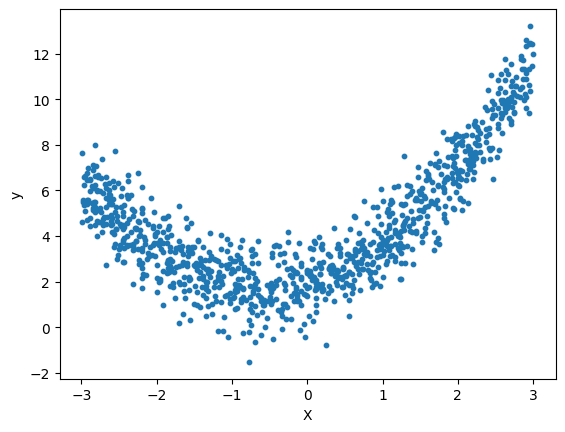

In [ ]:
plt.scatter(df['x'], df['y'] , s = 10)

plt.xlabel("X")
plt.ylabel("y")
plt.show()

## Applying Linear regression to this non linear data

In [ ]:
# Train test split
x_train , x_test , y_train , y_test = train_test_split(df['x'] , df['y'], test_size = 0.2 , random_state = 2 )

x_train = x_train.to_frame()
x_test = x_test.to_frame()

x_train

,x
175,1.30
818,-2.84
677,-2.44
952,0.18
200,-1.80
...,...
534,-2.19
584,0.69
493,0.95
527,-2.80


In [ ]:
y_train

175    2.804559
818    6.119776
677    3.472457
952    2.598389
200    2.890245
         ...   
534    5.193753
584    2.313039
493    3.596199
527    5.952975
168    8.802350
Name: y, Length: 800, dtype: float64

In [ ]:
# Applying linear regression
lr = LinearRegression()

In [ ]:
lr.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = lr.predict(x_test)
y_pred

array([2.2942573 , 4.82053783, 4.63624989, 5.24286436, 5.22750704,
       4.17553004, 2.8317638 , 5.81876418, 4.59017791, 4.38285397,
       3.81463282, 5.5576896 , 4.25999534, 3.22337567, 5.67286956,
       5.26590036, 2.209792  , 4.1832087 , 5.08161242, 4.37517531,
       3.60730888, 5.65751223, 5.72662021, 4.68232188, 2.51693857,
       2.39407994, 4.08338607, 6.29484136, 4.84357382, 2.46318792,
       3.27712632, 2.90855044, 2.57836788, 2.17907734, 6.52520129,
       4.20624469, 4.24463802, 6.24109071, 4.95875379, 6.21037606,
       6.03376678, 4.83589516, 6.55591595, 5.76501353, 4.09106473,
       3.3462343 , 2.87015712, 5.24286436, 5.41179498, 5.90322949,
       3.27712632, 2.90855044, 5.18911371, 5.84947884, 2.22514933,
       5.76501353, 5.81876418, 6.57127327, 2.95462243, 3.24641167,
       3.65338087, 4.22160202, 6.10287476, 2.36336528, 4.36749664,
       5.28125769, 3.97588477, 5.47322429, 5.48090295, 2.25586398,
       4.72839386, 2.85479979, 3.63034488, 5.19679238, 5.42715

### as expected the results are bad, as the data has non linear relationship

In [ ]:
r2_score(y_test,y_pred)

0.29637964220137203

In [ ]:
mean_absolute_percentage_error(y_test,y_pred) * 100

96.74254132304281

### best fit line of L.R

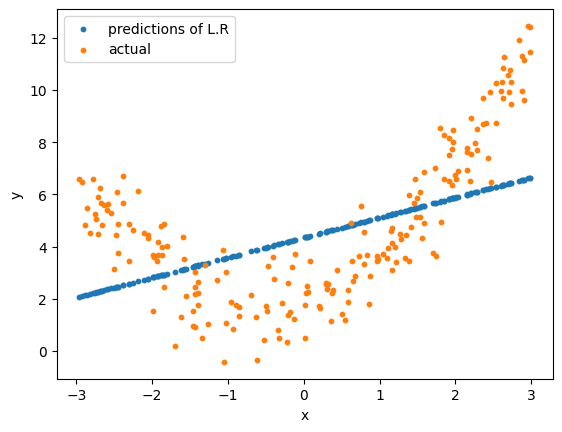

In [ ]:
plt.scatter(x_test['x'], lr.predict(x_test), s = 10 ,label = 'predictions of L.R' )
plt.scatter(x_test['x'], y_test, s = 10 , label = 'actual')

plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.show()

# Applying Polynomial Linear Regression

In [ ]:
# degree 2
poly = PolynomialFeatures(degree = 2 , include_bias = False)

# If `True` (default), then include a bias column, the feature in which 
# all polynomial powers are zero (i.e. a column of ones - acts as an intercept term in a linear model).

In [ ]:
x_train_trans = poly.fit_transform(x_train)

In [ ]:
x_train_trans

array([[ 1.3   ,  1.69  ],
       [-2.84  ,  8.0656],
       [-2.44  ,  5.9536],
       ...,
       [ 0.95  ,  0.9025],
       [-2.8   ,  7.84  ],
       [ 2.26  ,  5.1076]], shape=(800, 2))

In [ ]:
1.87 ** 2

3.4969000000000006

In [ ]:
x_train # orginal data

,x
175,1.30
818,-2.84
677,-2.44
952,0.18
200,-1.80
...,...
534,-2.19
584,0.69
493,0.95
527,-2.80


In [ ]:
x_test_trans = poly.transform(x_test)

In [ ]:
x_test # original x test

,x
37,-2.67
726,0.62
846,0.38
295,1.17
924,1.15
...,...
839,1.97
810,-1.02
930,-2.96
616,-1.43


In [ ]:
print('Input' , poly.n_features_in_)
print('Ouput' , poly.n_output_features_)
print('Powers \n' , poly.powers_)

Input 1
Ouput 2
Powers 
 [[1]
 [2]]


In [ ]:
pd.DataFrame(x_test_trans, columns = ['x' , 'x^2'])

,x,x^2
0,-2.67,7.1289
1,0.62,0.3844
2,0.38,0.1444
3,1.17,1.3689
4,1.15,1.3225
...,...,...
195,1.97,3.8809
196,-1.02,1.0404
197,-2.96,8.7616
198,-1.43,2.0449


In [ ]:
lr = LinearRegression()
lr.fit(x_train_trans , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = lr.predict(x_test_trans)
y_pred

array([ 5.19406992,  2.87976488,  2.47853715,  4.13761637,  4.08362145,
        1.86796294,  3.28977248,  6.61215951,  2.3922479 ,  2.07333381,
        1.78131827,  5.38180746,  1.93792637,  2.38292866,  5.90241517,
        4.21977687,  5.56270419,  1.87354449,  3.60174233,  2.0637027 ,
        1.88713994,  5.83097603,  6.15735834,  2.57043348,  4.31255212,
        4.78270856,  1.81313297,  9.3192607 ,  2.9362263 ,  4.51333937,
        2.29007756,  3.0800308 ,  4.09242609,  5.70142557, 10.84408616,
        1.89122366,  1.92380398,  8.98363798,  3.23955994,  8.79528011,
        7.76058337,  2.91725008, 11.05798736,  6.34413317,  1.81684549,
        2.18191172,  3.18295474,  4.13761637,  4.77267893,  7.04876322,
        2.29007756,  3.0800308 ,  3.95135984,  6.76874397,  5.494278  ,
        6.34413317,  6.61215951, 11.16587248,  2.96166189,  2.34220081,
        1.85381164,  1.90378853,  8.15565233,  4.90647775,  2.05422735,
        4.2753293 ,  1.77751154,  5.02230101,  5.05420465,  5.35

In [ ]:
print( 'r2   : ' , r2_score(y_test,y_pred) )
print( 'mape   : ' , mean_absolute_percentage_error(y_test,y_pred) * 100 ) # high beacuse scale of data is less, deviation by one number increase mape approx. 33%

r2   :  0.8791478717341716
mape   :  43.151073191727974


In [ ]:
print('coef   : '  , lr.coef_)
print('intercept   : ' , lr.intercept_)

coef   :  [0.89302208 0.77876013]
intercept   :  2.0267358020322925


In [ ]:
y_pred[:10]

array([5.19406992, 2.87976488, 2.47853715, 4.13761637, 4.08362145,
       1.86796294, 3.28977248, 6.61215951, 2.3922479 , 2.07333381])

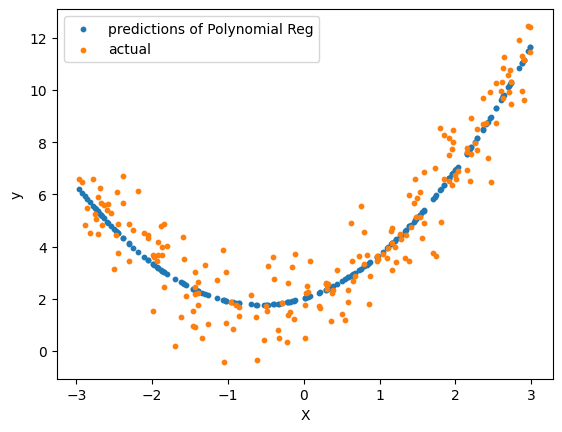

In [ ]:
plt.scatter(x_test['x'], y_pred, s = 10 ,label = 'predictions of Polynomial Reg' )
plt.scatter(x_test['x'], y_test, s = 10 , label = 'actual')

plt.xlabel("X")
plt.ylabel("y")

plt.legend()
plt.show()

In [ ]:
def polynomial_regression(degree):

    poly = PolynomialFeatures(degree = degree)
    
    x_train_trans = poly.fit_transform(x_train)
    x_test_trans = poly.transform(x_test)

    lr = LinearRegression()
    lr.fit(x_train_trans , y_train)
    
    y_pred = lr.predict(x_test_trans)
    # print( 'r2   : ' , r2_score(y_test,y_pred).round(2) )

    plt.scatter(x_test['x'], y_pred, s = 10 ,label = f'predictions of Polynomial Reg with degree {degree}' )
    plt.scatter(x_test['x'], y_test, s = 10 , label = 'actual')
    
    plt.xlabel("X")
    plt.ylabel("y")
    
    plt.legend()
    plt.show()

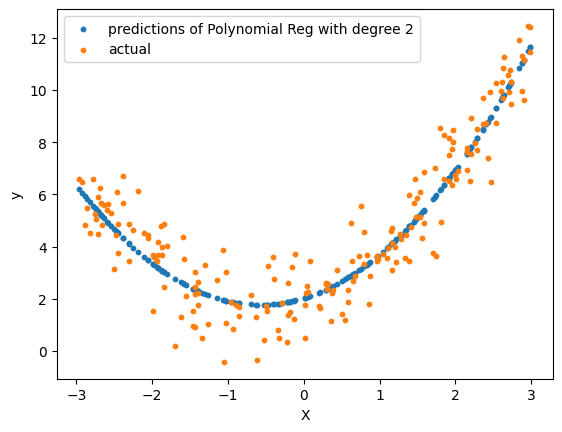

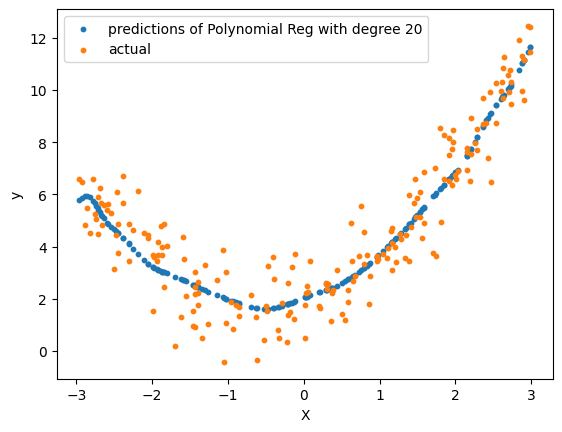

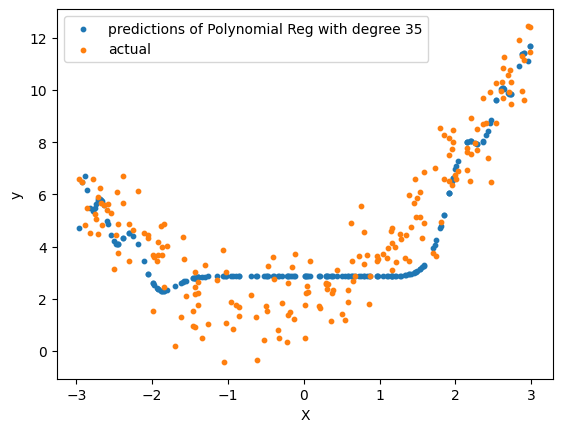

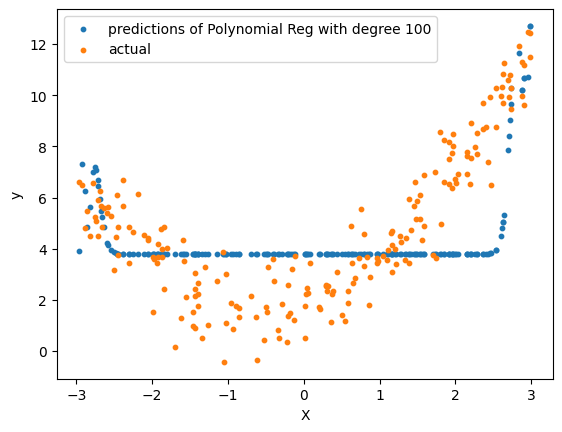

In [ ]:
polynomial_regression(2)
# polynomial_regression(5)
# polynomial_regression(10)
polynomial_regression(20)
# polynomial_regression(30)
polynomial_regression(35)
polynomial_regression(100)

## On Data

In [ ]:
df = pd.read_csv("../data/insurance.csv")
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [ ]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


<Axes: >

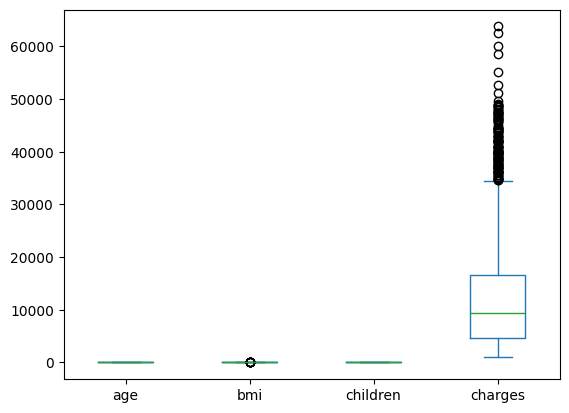

In [ ]:
df.plot(kind = 'box')

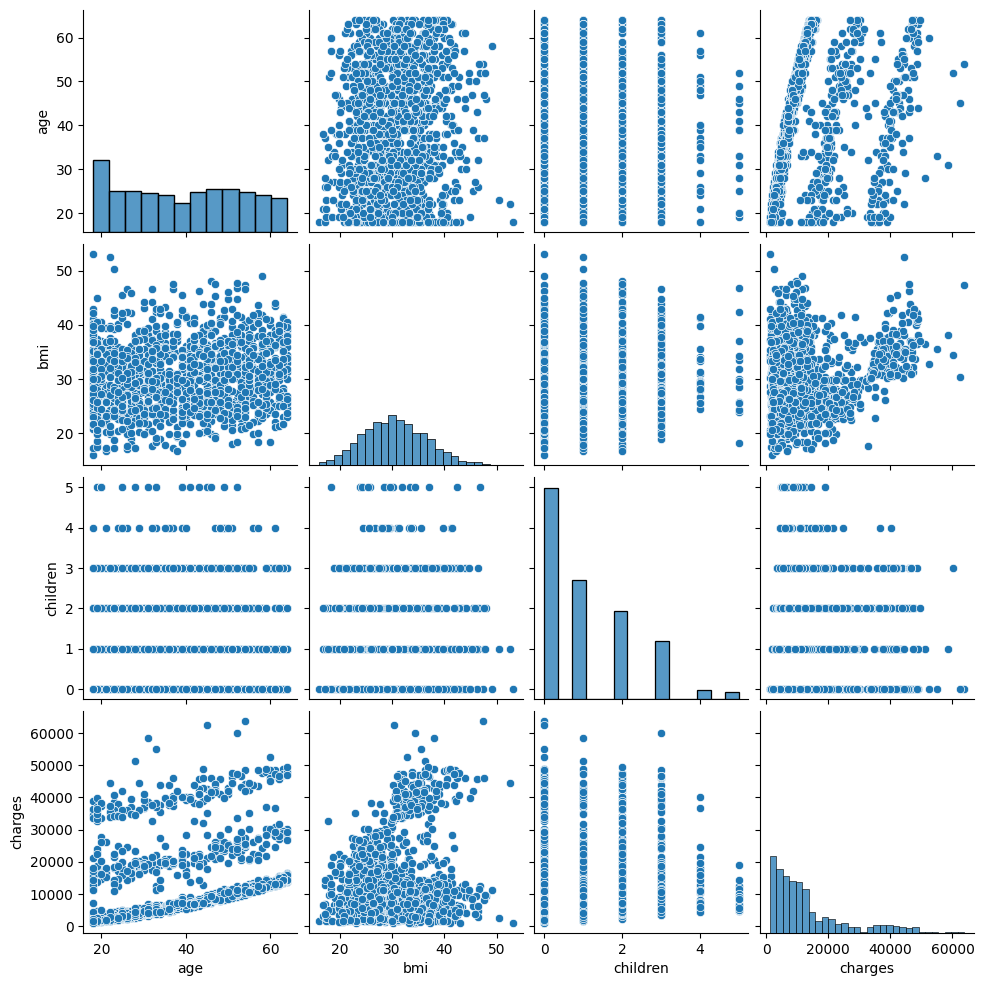

In [ ]:
sns.pairplot(df)

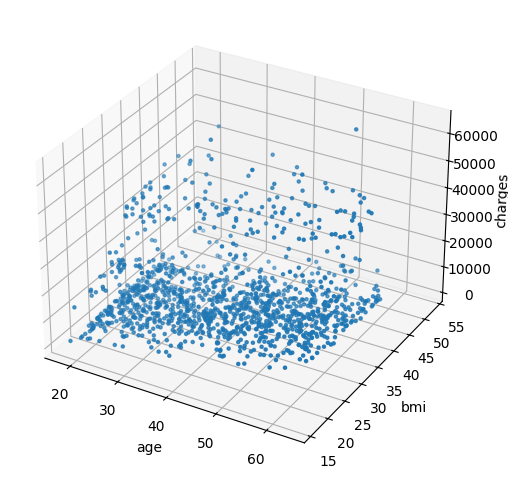

In [ ]:
fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(df['age'], df['bmi'], df['charges'], s = 5)

ax.set_xlabel('age')
ax.set_ylabel('bmi')
ax.set_zlabel('charges')

plt.show()

In [ ]:
print(df['sex'].unique())
df['sex'] = df['sex'].map({'female': 1, 'male': 2})

<StringArray>
['female', 'male']
Length: 2, dtype: str


In [ ]:
print(df['smoker'].unique())
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 2})

<StringArray>
['yes', 'no']
Length: 2, dtype: str


In [ ]:
print(df['region'].unique())
df['region'] = df['region'].map({'southwest': 1, 'southeast': 2, 'northwest': 3, 'northeast': 4})

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [ ]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
df.corr().round(2)

,age,sex,bmi,children,smoker,region,charges
age,1.00,-0.02,0.11,0.04,0.03,-0.00,0.30
sex,-0.02,1.00,0.05,0.02,-0.08,-0.00,0.06
bmi,0.11,0.05,1.00,0.01,-0.00,-0.16,0.20
children,0.04,0.02,0.01,1.00,-0.01,-0.02,0.07
smoker,0.03,-0.08,-0.00,-0.01,1.00,-0.00,-0.79
region,-0.00,-0.00,-0.16,-0.02,-0.00,1.00,0.01
charges,0.30,0.06,0.20,0.07,-0.79,0.01,1.00


## Defining Input Features and Target Variable

In [ ]:
x = df.drop(columns = ['charges'])
y = df['charges']

## Split for Training and Testing

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

## Linear regression

In [ ]:
lr = LinearRegression()

lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

print(r2_score(y_test, y_pred))
print( 'mape   : ' , mean_absolute_percentage_error(y_test,y_pred))

0.7608850455234247
mape   :  0.5198730052267007


### Polynomial regression

In [ ]:
poly = PolynomialFeatures(degree = 2)

x_poly_train = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

lr = LinearRegression()

lr.fit(x_poly_train, y_train)
y_pred = lr.predict(x_test_poly)

print(r2_score(y_test, y_pred))
print( 'mape   : ' , mean_absolute_percentage_error(y_test,y_pred) )

0.8455815021524012
mape   :  0.3124404171848718


In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,2,33.770,1,2,2,1725.55230
2,28,2,33.000,3,2,2,4449.46200
3,33,2,22.705,0,2,3,21984.47061
4,32,2,28.880,0,2,3,3866.85520
...,...,...,...,...,...,...,...
1333,50,2,30.970,3,2,3,10600.54830
1334,18,1,31.920,0,2,4,2205.98080
1335,18,1,36.850,0,2,2,1629.83350
1336,21,1,25.800,0,2,1,2007.94500


In [ ]:
print('Input' , poly.n_features_in_)
print('Ouput' , poly.n_output_features_)
print('Powers \n' , poly.powers_)

Input 6
Ouput 28
Powers 
 [[0 0 0 0 0 0]
 [1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]
 [2 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 0 1 0 0 0]
 [1 0 0 1 0 0]
 [1 0 0 0 1 0]
 [1 0 0 0 0 1]
 [0 2 0 0 0 0]
 [0 1 1 0 0 0]
 [0 1 0 1 0 0]
 [0 1 0 0 1 0]
 [0 1 0 0 0 1]
 [0 0 2 0 0 0]
 [0 0 1 1 0 0]
 [0 0 1 0 1 0]
 [0 0 1 0 0 1]
 [0 0 0 2 0 0]
 [0 0 0 1 1 0]
 [0 0 0 1 0 1]
 [0 0 0 0 2 0]
 [0 0 0 0 1 1]
 [0 0 0 0 0 2]]


In [ ]:
x_poly_train

array([[ 1., 41.,  1., ...,  4.,  2.,  1.],
       [ 1., 32.,  1., ...,  1.,  3.,  9.],
       [ 1., 55.,  2., ...,  4.,  2.,  1.],
       ...,
       [ 1., 57.,  1., ...,  4.,  4.,  4.],
       [ 1., 60.,  2., ...,  1.,  1.,  1.],
       [ 1., 53.,  1., ...,  4.,  8., 16.]], shape=(1070, 28))

In [ ]:
pd.DataFrame(x_poly_train, columns = range(1 , x_poly_train[0].shape[0] + 1))

,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,28
0,1.0,41.0,1.0,32.600,3.0,2.0,1.0,1681.0,41.0,1336.600,...,1062.760000,97.800,65.200,32.600,9.0,6.0,3.0,4.0,2.0,1.0
1,1.0,32.0,1.0,17.765,2.0,1.0,3.0,1024.0,32.0,568.480,...,315.595225,35.530,17.765,53.295,4.0,2.0,6.0,1.0,3.0,9.0
2,1.0,55.0,2.0,37.300,0.0,2.0,1.0,3025.0,110.0,2051.500,...,1391.290000,0.000,74.600,37.300,0.0,0.0,0.0,4.0,2.0,1.0
3,1.0,29.0,2.0,27.940,0.0,2.0,2.0,841.0,58.0,810.260,...,780.643600,0.000,55.880,55.880,0.0,0.0,0.0,4.0,4.0,4.0
4,1.0,27.0,1.0,31.255,1.0,2.0,3.0,729.0,27.0,843.885,...,976.875025,31.255,62.510,93.765,1.0,2.0,3.0,4.0,6.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,1.0,42.0,2.0,34.100,0.0,2.0,1.0,1764.0,84.0,1432.200,...,1162.810000,0.000,68.200,34.100,0.0,0.0,0.0,4.0,2.0,1.0
1066,1.0,18.0,1.0,26.730,0.0,2.0,2.0,324.0,18.0,481.140,...,714.492900,0.000,53.460,53.460,0.0,0.0,0.0,4.0,4.0,4.0
1067,1.0,57.0,1.0,23.980,1.0,2.0,2.0,3249.0,57.0,1366.860,...,575.040400,23.980,47.960,47.960,1.0,2.0,2.0,4.0,4.0,4.0
1068,1.0,60.0,2.0,32.800,0.0,1.0,1.0,3600.0,120.0,1968.000,...,1075.840000,0.000,32.800,32.800,0.0,0.0,0.0,1.0,1.0,1.0


In [ ]:
x_poly_train[0].shape

(28,)

In [ ]:
lr.coef_

array([ 1.10545330e-08, -1.81444150e+02, -1.75671648e+02,  3.43157402e+03,
        4.88026621e+02,  1.97024504e+03, -1.19884958e+03,  4.42613273e+00,
        2.70605195e+01,  1.72476932e+00, -1.22719786e+00,  1.75457254e+01,
       -1.40870526e+01, -5.27014945e+02,  2.13114376e+01, -2.42295600e+02,
       -4.43383843e+01, -5.56444059e+01, -9.95690739e+00, -2.47557109e+00,
       -1.48148421e+03,  2.54271325e+01, -1.60236231e+02,  5.49362931e+02,
        1.00869264e+02,  5.91073512e+03,  1.81156065e+02,  2.00469224e+02])